This notebook runs the reduced-order model (ROM) experiments for the parametric wave equation.

The full-order model (FOM) is a finite element discretization of the 2D wave equation on $[0, 2\pi]^2$ with uniform wave speed. The system is forced by a spatially localized Gaussian source centered at $(x_0, y_0)$ with a $\sin(x/2)\sin(y/2)$ envelope, oscillating in time at frequency $\omega$. The three parameters are $\mu = (\omega, x_0, y_0)$, with 160 training and 40 test samples over $t \in [0, 8\pi]$.

A Tucker decomposition of the snapshot tensor is used to build parameter-dependent reduced bases. Three basis construction methods are compared:
- **Monolithic**: a single global SVD basis computed from all training snapshots
- **Radial Basis Functions (RBF)**: a parameter-interpolated basis using Gaussian RBF weights on the Tucker parameter factor
- **Mamonov/Olshanskii (MO)**: a locally informed basis using MO interpolation weights

ROM errors and projection errors are reported for both displacement ($Q$) and momentum ($P$) fields across a sweep of basis sizes and Tucker core ranks.

# Scripts

In [1]:
# Generate FOM snapshots and save to disk
!python generate_data.py

Saving to: data/Wave
Total sampled parameters:  200
Training parameters:  160
Single sample run: 
Parametric wave equation finite element model
  Spatial domain (2D): [0, 6.2832] x [0, 6.2832]
  Discretization size: 2160
Run for all parameters:
no more timer available (lff_from_py), reusing last one
Saving files done!


In [2]:
# Compute Tucker decomposition of snapshot tensor
!python tucker.py

Saving to: data/Wave
Loading data
X.shape=(2160, 1002, 160)
Tucker: 60x60x60


reconstruction error=0.041485333512071156, variation=3.113690062242491e-07.
converged in 2 iterations.
Tucker: 120x120x120
reconstruction error=0.009190703515239412, variation=4.602433710185205e-09.
converged in 2 iterations.
SVD
Saving SVD


# Imports

In [1]:
# Core imports and path/directory setup
import os
import sys
import numpy as np
import tensorly as tl

sys.path.insert(0, os.path.abspath("../.."))
savedir = "../../data/Wave"

In [2]:
# Problem-specific imports
import scipy.sparse as sp
from tensorly.tucker_tensor import TuckerTensor
from src.Wave.ROM import *
from src.Wave.FOM import WaveFEM2D
from src.Utils.utils import *
from src.Bases.rbf import RBFWeights
from src.Bases.mo import mo
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [3]:
# LaTeX matplotlib style
plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{bm}",
    "font.size": 20,
    "font.family": "serif",
    "axes.titlesize": 18,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
})

# Load data

In [4]:
# Time grid, FOM initialization, and mass matrix
t = np.linspace(0, 8*np.pi, 501)
fom = WaveFEM2D(L=2*np.pi, h=0.5, orderW=2, orderV=2, width=0.5/np.sqrt(2))
M_Q = fom.MW
print(fom)

Parametric wave equation finite element model
  Spatial domain (2D): [0, 6.2832] x [0, 6.2832]
  Discretization size: 2160


In [5]:
# Load training/test parameters and snapshots
with np.load(os.path.join(savedir, "params_train.npz")) as z:
    params_train = z["params"]
with np.load(os.path.join(savedir, "params_test.npz")) as z:
    params_test = z["params"]

with np.load(os.path.join(savedir, "wave_train.npz")) as z:
    snapshots_Q_train = z["Q"]
    snapshots_P_train = z["P"]

with np.load(os.path.join(savedir, "wave_test.npz")) as z:
    snapshots_Q_test = z["Q"]
    snapshots_P_test = z["P"]

snapshots_Q_train.shape, snapshots_Q_test.shape, params_train.shape, params_test.shape

((160, 2160, 501), (40, 2160, 501), (160, 3), (40, 3))

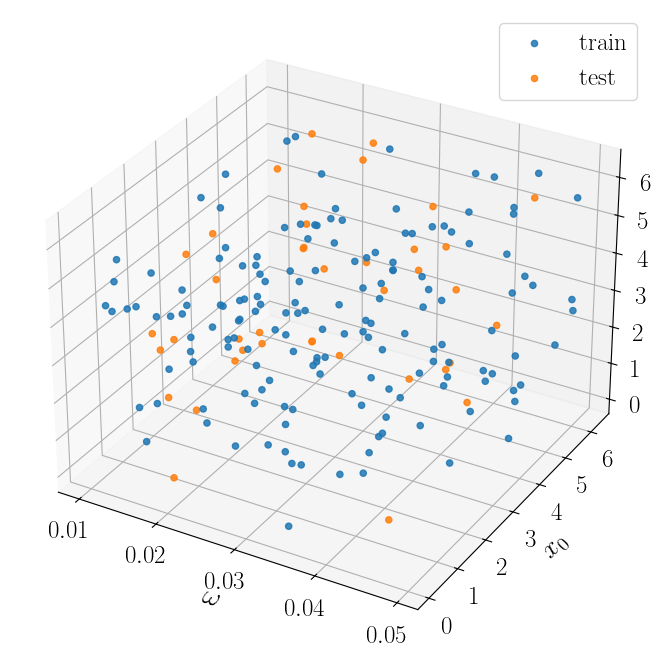

In [6]:
# Scatter plot of train/test parameter distribution
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(params_train[:,0], params_train[:,1], params_train[:,2],
           c="tab:blue", s=20, alpha=0.85, label="train")
ax.scatter(params_test[:,0],  params_test[:,1],  params_test[:,2],
           c="tab:orange", s=20, alpha=0.85, label="test")
ax.set_xlabel(r"$\omega$"); ax.set_ylabel("$x_0$"); ax.set_zlabel("$y_0$")
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# Load monolithic SVD basis and verify M-orthonormality
data = np.load(os.path.join(savedir, "svd_rank120_Mortho.npz"))
U_mono, S_mono = data["U"], data["S"]
print("Check for MW-orthonormality: ||U^T MW U - I|| =",
      np.linalg.norm(U_mono.T @ M_Q @ U_mono - np.eye(U_mono.shape[1])))

Check for MW-orthonormality: ||U^T MW U - I|| = 3.817597375086015e-14


In [8]:
# Load Tucker decomposition
core, factors = load_tucker_npz(os.path.join(savedir, "tucker_120x120x120_Mortho.npz"))
tucker_tensor = TuckerTensor((core, factors))
print("Tucker core shape:", core.shape)

Tucker core shape: (120, 120, 120)


In [9]:
# ROM rank values to sweep
r_arr = np.array([1, 5, 10, 20, 40, 60], dtype=int)

In [10]:
# Initialize Radial Basis Function interpolant on training parameters
rbfw = RBFWeights(
    mus=params_train,
    basis="gaussian",
    eps=1,
    order=-1,
    nugget=0,
)

# Single parameter predictions

In [11]:
# Select a single test parameter for the experiments
idx       = -1
r_idx_rbf = 4
r_idx_mo = 4
r_idx_mono = 4

mu = params_test[idx]   # [omega, x0, y0]
print(f"mu = omega={mu[0]:.3f}, x0={mu[1]:.3f}, y0={mu[2]:.3f}")
print(r_arr[r_idx_rbf])

mu = omega=0.029, x0=2.377, y0=6.155
40


In [12]:
# Build RBF basis, solve ROM, compute projection and ROM errors
W_rbf = rbfw.weights(params_test[idx])
U_rbf, s_rbf, _ = buildParBasis(tucker_tensor, W_rbf)

print("MW-orthonormality: ||U^T MW U - I|| =",
      np.linalg.norm(U_rbf.T @ M_Q @ U_rbf - np.eye(U_rbf.shape[1])))
print("Projection error  (MW,Q) :", projection_error_M(snapshots_Q_test[idx],
      U_rbf[:, :r_arr[r_idx_rbf]], M_Q, Mnorm))

ROM_rbf = WavePODROM(fom, U_rbf[:, :r_arr[r_idx_rbf]])
Qr_rbf, Pr_rbf, Ur_rbf = ROM_rbf.solve(t, mu[0], mu[1], mu[2])
Q_rbf = Ur_rbf @ Qr_rbf
P_rbf = Ur_rbf @ Pr_rbf

QP_true = np.concatenate([snapshots_Q_test[idx], snapshots_P_test[idx]], axis=1)
QP_rbf  = np.concatenate([Q_rbf, P_rbf], axis=1)

print("ROM error (MW, Q) :",
      Mnorm(snapshots_Q_test[idx] - Q_rbf, M_Q) / Mnorm(snapshots_Q_test[idx], M_Q))
print("Projection error  (MW,QP):", projection_error_M(
      np.concatenate([snapshots_Q_test[idx], snapshots_P_test[idx]], axis=1),
      U_rbf[:, :r_arr[r_idx_rbf]], M_Q, Mnorm))
print("ROM error (MW, QP):",
      Mnorm(QP_true - QP_rbf, M_Q) / Mnorm(QP_true, M_Q))


MW-orthonormality: ||U^T MW U - I|| = 4.0464835089428774e-14
Projection error  (MW,Q) : 0.03400412547945554
ROM error (MW, Q) : 0.03471964098218486
Projection error  (MW,QP): 0.08525550048873
ROM error (MW, QP): 0.08750812639537818


In [13]:
# Solve ROM with monolithic basis, compute errors
ROM_mono = WavePODROM(fom, U_mono[:, :r_arr[r_idx_mono]])
Qr_mono, Pr_mono, Ur_mono = ROM_mono.solve(t, mu[0], mu[1], mu[2])
Q_mono = Ur_mono @ Qr_mono
P_mono = Ur_mono @ Pr_mono

QP_true = np.concatenate([snapshots_Q_test[idx], snapshots_P_test[idx]], axis=1)
QP_mono = np.concatenate([Q_mono, P_mono], axis=1)
print("MW-orthonormality: ||U^T MW U - I|| =",
      np.linalg.norm(Ur_mono.T @ M_Q @ Ur_mono - np.eye(Ur_mono.shape[1])))

print("Projection error  (MW,Q) :", projection_error_M(snapshots_Q_test[idx],
      Ur_mono, M_Q, Mnorm))
print("ROM error (MW, Q) :",
      Mnorm(snapshots_Q_test[idx] - Q_mono, M_Q) / Mnorm(snapshots_Q_test[idx], M_Q))
print("Projection error  (MW,QP):", projection_error_M(QP_true,
      Ur_mono, M_Q, Mnorm))
print("ROM error (MW, QP):",
      Mnorm(QP_true - QP_mono, M_Q) / Mnorm(QP_true, M_Q))


MW-orthonormality: ||U^T MW U - I|| = 1.886788347809336e-14
Projection error  (MW,Q) : 0.1141589741685602
ROM error (MW, Q) : 0.11913466260283434
Projection error  (MW,QP): 0.24411940126131337
ROM error (MW, QP): 0.26192223522676844


In [14]:
# Build MO basis, solve ROM, compute errors
W_mo = mo(params_train, 15, params_test[idx], eps=1e-16, rcond=1e-16)
U_mo, _, _ = buildParBasis(tucker_tensor, W_mo)

QP_true = np.concatenate([snapshots_Q_test[idx], snapshots_P_test[idx]], axis=1)
print("MW-orthonormality: ||U^T MW U - I|| =",
      np.linalg.norm(U_mo[:, :r_arr[r_idx_mo]].T @ M_Q @ U_mo[:, :r_arr[r_idx_mo]] - np.eye(r_arr[r_idx_mo])))

print("Projection error  (MW,Q) :", projection_error_M(snapshots_Q_test[idx],
      U_mo[:, :r_arr[r_idx_mo]], M_Q, Mnorm))

ROM_mo = WavePODROM(fom, U_mo[:, :r_arr[r_idx_mo]])
Qr_mo, Pr_mo, Ur_mo = ROM_mo.solve(t, mu[0], mu[1], mu[2])
Q_mo = Ur_mo @ Qr_mo
P_mo = Ur_mo @ Pr_mo

QP_mo = np.concatenate([Q_mo, P_mo], axis=1)

print("ROM error (MW, Q) :",
      Mnorm(snapshots_Q_test[idx] - Q_mo, M_Q) / Mnorm(snapshots_Q_test[idx], M_Q))
print("Projection error  (MW,QP):", projection_error_M(QP_true,
      U_mo[:, :r_arr[r_idx_mo]], M_Q, Mnorm))
print("ROM error (MW, QP):",
      Mnorm(QP_true - QP_mo, M_Q) / Mnorm(QP_true, M_Q))


MW-orthonormality: ||U^T MW U - I|| = 1.661478303844975e-14
Projection error  (MW,Q) : 0.36975479244520104
ROM error (MW, Q) : 0.37308328335890756
Projection error  (MW,QP): 0.3620329364396636
ROM error (MW, QP): 0.36985061063738467


## Plots

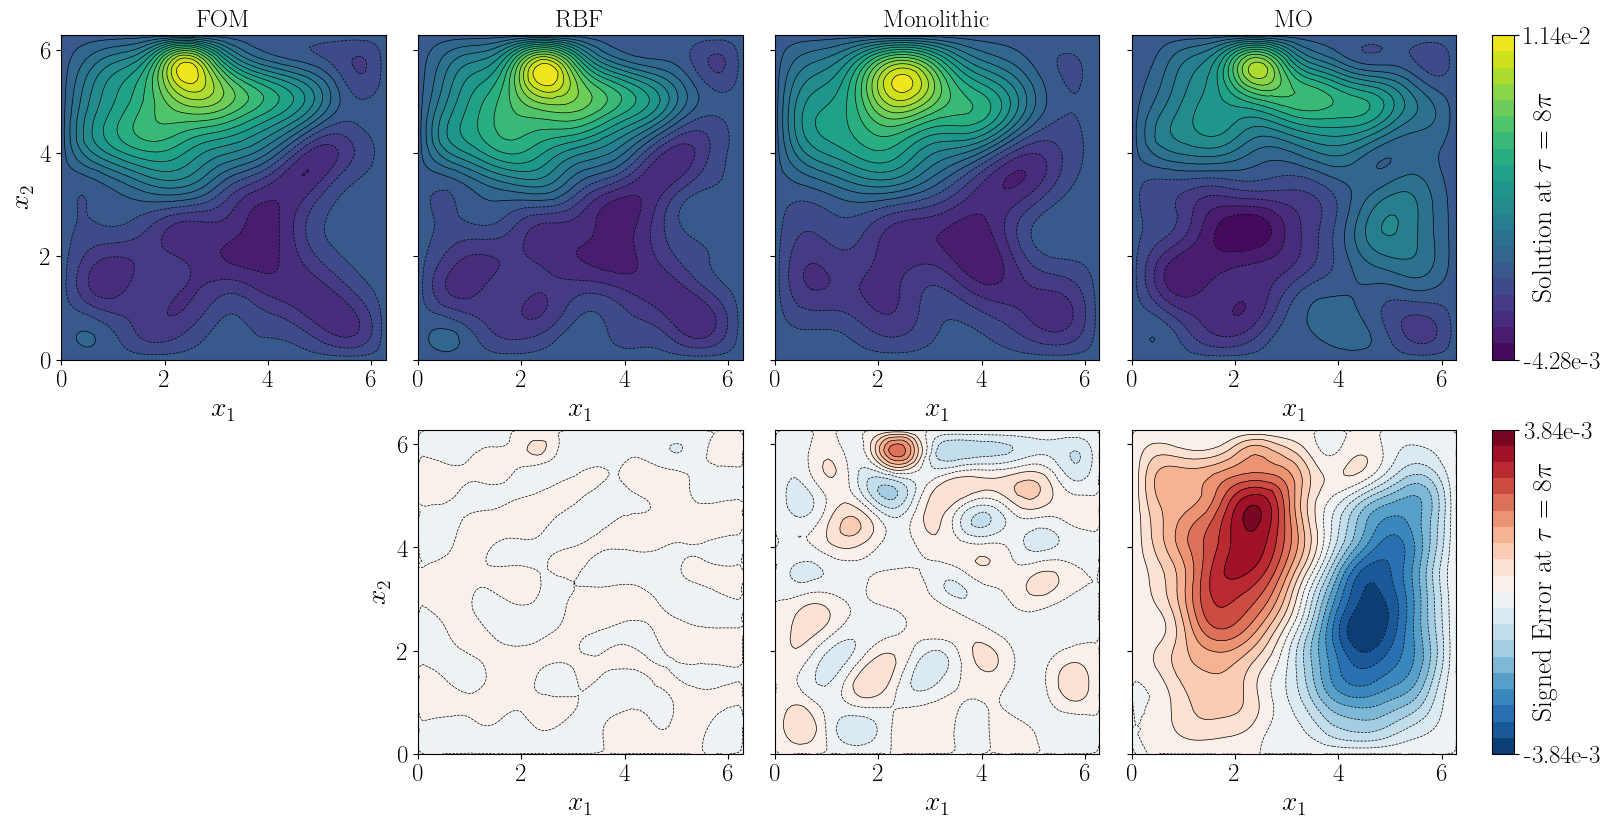

In [15]:
# Plot FOM vs ROM solution contours and signed errors
from src.Wave.plots import eval_grid, plot_contours

N     = 80
t_idx = -1

Z_fom  = eval_grid(fom, snapshots_Q_test[idx][:, t_idx])
Z_rbf  = eval_grid(fom, Q_rbf[:, t_idx])
Z_mono = eval_grid(fom, Q_mono[:, t_idx])
Z_mo  = eval_grid(fom, Q_mo[:, t_idx])

plot_contours(fom, Z_fom, Z_rbf, Z_mono, Z_mo,
              sol_label=rf"Solution at $\tau = 8\pi$",
              err_label=rf"Signed Error at $\tau = 8\pi$")
plt.savefig("solution_wave.pdf", bbox_inches='tight')
plt.show()


# Parameter sweep

In [16]:
# Error sweep function and per-method basis builders
def wave_sweep_dataset(fom, params, r_arr, snapshots_Q, snapshots_P, t, M_Q,
                       basis_builder, label=""):
    """ROM and projection-error sweep over a dataset.

    Returns
    -------
    rom_Q, proj_Q, rom_P, proj_P : each (len(r_arr), n_cases)
    """
    r_arr  = np.asarray(r_arr, dtype=int)
    rmax   = int(np.max(r_arr))
    n_cases = params.shape[0]

    rom_Q  = np.zeros((len(r_arr), n_cases))
    proj_Q = np.zeros((len(r_arr), n_cases))
    rom_P  = np.zeros((len(r_arr), n_cases))
    proj_P = np.zeros((len(r_arr), n_cases))

    for idx in range(n_cases):
        mu      = params[idx]
        Q_truth = snapshots_Q[idx]
        P_truth = snapshots_P[idx]
        denomQ  = Mnorm(Q_truth, M_Q)
        denomP  = Mnorm(P_truth, M_Q)

        U_max = basis_builder(mu, rmax)
        ROM   = WavePODROM(fom, U_max)

        for r_idx, r in enumerate(r_arr):
            Qr, Pr, Ur = ROM.solve(t, mu[0], mu[1], mu[2], r=int(r))
            Q_full = Ur @ Qr
            P_full = Ur @ Pr
            rom_Q [r_idx, idx] = Mnorm(Q_truth - Q_full, M_Q) / denomQ
            proj_Q[r_idx, idx] = projection_error_M(Q_truth, Ur, M_Q, Mnorm)
            rom_P [r_idx, idx] = Mnorm(P_truth - P_full, M_Q) / denomP
            proj_P[r_idx, idx] = projection_error_M(P_truth, Ur, M_Q, Mnorm)

        if label:
            print(f"{label}: {idx+1}/{n_cases}", end="\r")
    print()
    return rom_Q, proj_Q, rom_P, proj_P


# Basis builders (return (Nx, rmax) basis for a given mu)
def build_mono(mu, rmax):
    return U_mono[:, :rmax]

def build_rbf(mu, rmax):
    W = rbfw.weights(mu)
    U, _, _ = buildParBasis(tucker_tensor, W)
    return U[:, :rmax]

def build_mo(mu, rmax, k=15, eps=1e-16, rcond=1e-16):
    W = mo(params_train, k, mu, eps=eps, rcond=rcond)
    U, _, _ = buildParBasis(tucker_tensor, W)
    return U[:, :rmax]


In [ ]:
# Sweep errors over the test set
mono_rom_te, mono_proj_te, mono_rom_P_te, mono_proj_P_te = wave_sweep_dataset(
    fom, params_test, r_arr, snapshots_Q_test, snapshots_P_test, t, M_Q, build_mono, label="mono test")

rbf_rom_te, rbf_proj_te, rbf_rom_P_te, rbf_proj_P_te = wave_sweep_dataset(
    fom, params_test, r_arr, snapshots_Q_test, snapshots_P_test, t, M_Q, build_rbf, label="rbf test")

mo_rom_te, mo_proj_te, mo_rom_P_te, mo_proj_P_te = wave_sweep_dataset(
    fom, params_test, r_arr, snapshots_Q_test, snapshots_P_test, t, M_Q, build_mo, label="mo test")


mono test: 40/40
rbf test: 40/40
lid test: 40/40


In [ ]:
# Sweep errors over the training set
mono_rom_tr, mono_proj_tr, mono_rom_P_tr, mono_proj_P_tr = wave_sweep_dataset(
    fom, params_train, r_arr, snapshots_Q_train, snapshots_P_train, t, M_Q, build_mono, label="mono train")

rbf_rom_tr, rbf_proj_tr, rbf_rom_P_tr, rbf_proj_P_tr = wave_sweep_dataset(
    fom, params_train, r_arr, snapshots_Q_train, snapshots_P_train, t, M_Q, build_rbf, label="rbf train")

mo_rom_tr, mo_proj_tr, mo_rom_P_tr, mo_proj_P_tr = wave_sweep_dataset(
    fom, params_train, r_arr, snapshots_Q_train, snapshots_P_train, t, M_Q, build_mo, label="mo train")


mono train: 160/160
rbf train: 160/160
lid train: 160/160


In [ ]:
# Save all sweep results to disk
np.savez(
    os.path.join(savedir, "errors_120x120x120.npz"),
    r_arr=r_arr,
    params_train=params_train,
    params_test=params_test,

    mono_rom_train=mono_rom_tr,    mono_proj_train=mono_proj_tr,
    mono_rom_test=mono_rom_te,     mono_proj_test=mono_proj_te,
    mono_rom_P_train=mono_rom_P_tr, mono_proj_P_train=mono_proj_P_tr,
    mono_rom_P_test=mono_rom_P_te,  mono_proj_P_test=mono_proj_P_te,

    rbf_rom_train=rbf_rom_tr,      rbf_proj_train=rbf_proj_tr,
    rbf_rom_test=rbf_rom_te,       rbf_proj_test=rbf_proj_te,
    rbf_rom_P_train=rbf_rom_P_tr,  rbf_proj_P_train=rbf_proj_P_tr,
    rbf_rom_P_test=rbf_rom_P_te,   rbf_proj_P_test=rbf_proj_P_te,

    mo_rom_train=mo_rom_tr,      mo_proj_train=mo_proj_tr,
    mo_rom_test=mo_rom_te,       mo_proj_test=mo_proj_te,
    mo_rom_P_train=mo_rom_P_tr,  mo_proj_P_train=mo_proj_P_tr,
    mo_rom_P_test=mo_rom_P_te,   mo_proj_P_test=mo_proj_P_te,
)


/Users/arjunveejay/Documents/Code/Private repos/TuckerROMs/src/Wave/plots.py:80: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.16)


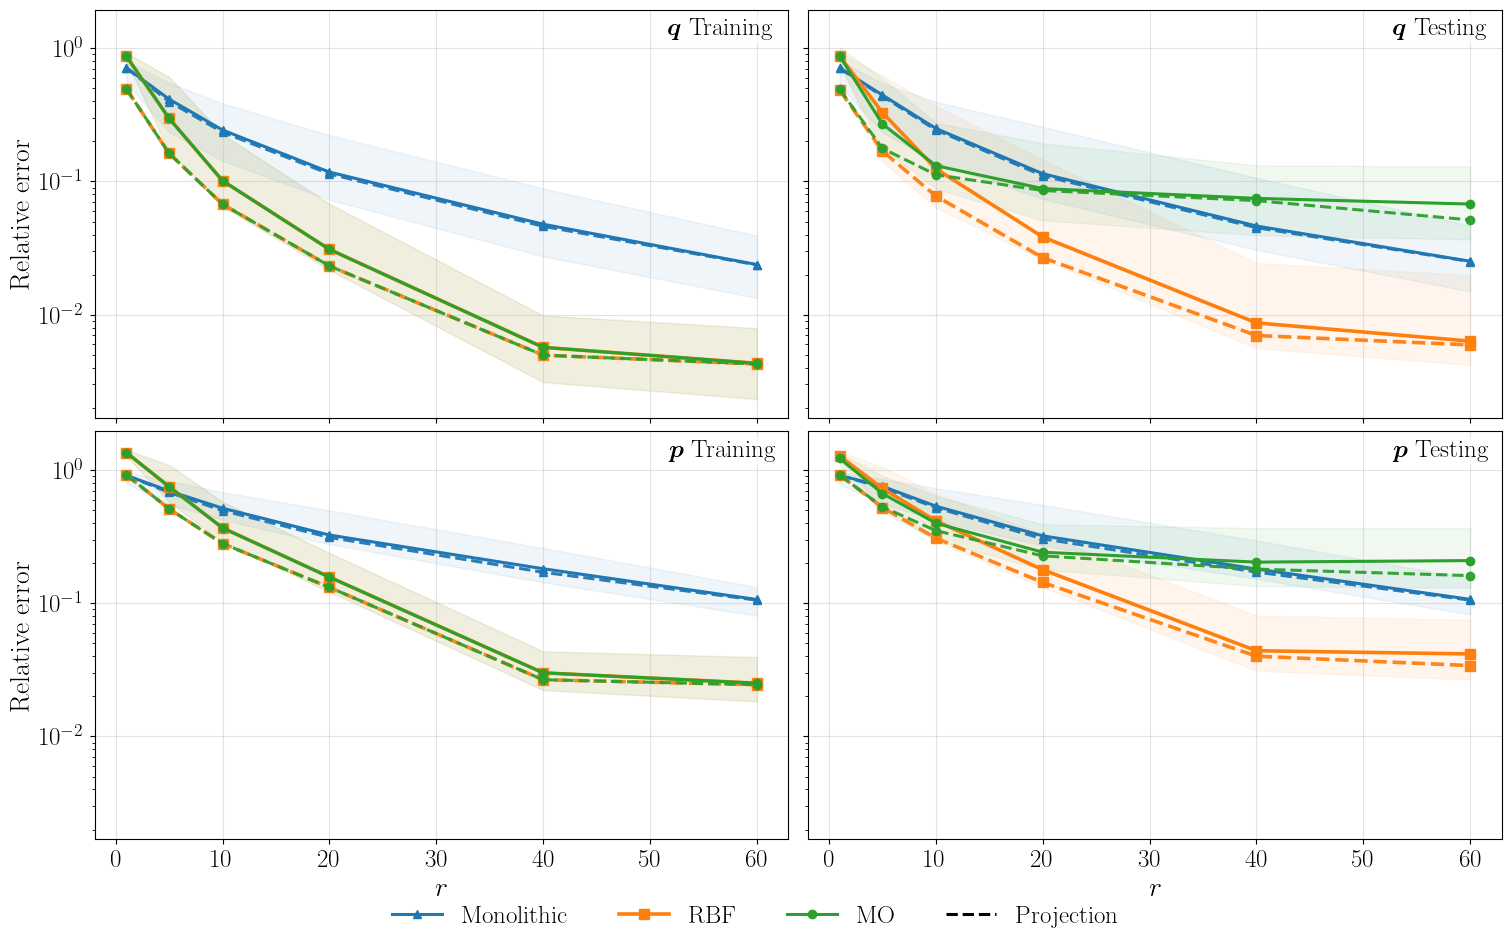

In [20]:
# Plot ROM and projection error curves for Tucker rank (120, 120, 120)
from src.Wave.plots import plot_errors
errs = np.load(os.path.join(savedir, "errors_120x120x120.npz"))
plot_errors(errs)
plt.savefig("errors_wave.pdf", bbox_inches='tight')
plt.show()


/Users/arjunveejay/Documents/Code/Private repos/TuckerROMs/src/Wave/plots.py:80: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.16)


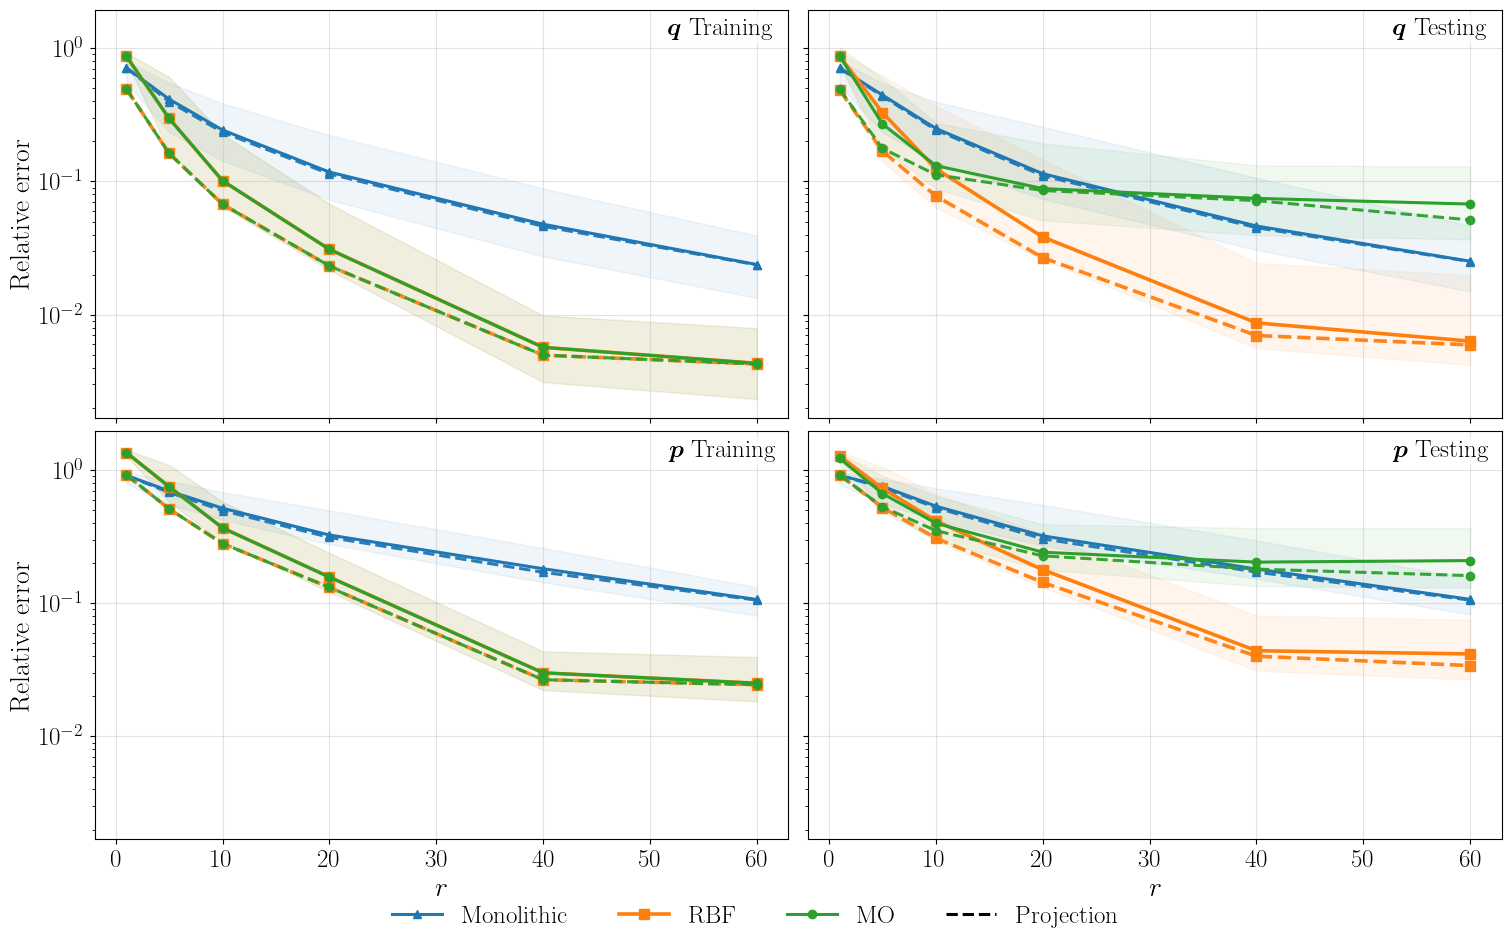

In [21]:
# Plot ROM and projection error curves for Tucker rank (60, 60, 60)
errs = np.load(os.path.join(savedir, "errors_60x60x60.npz"))
plot_errors(errs)
plt.show()
